# Introduction

Now it's time to experiment - I'll compare models trained  on the 224×224 resized versions of X-ray chest images, and on smaller 64×64 inputs to see how much resolution matters for classification.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torchvision.io import read_image
from torchvision.transforms import v2
from torchvision.utils import make_grid
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
#from torchvision import transforms as v2

# Go to project root
os.chdir("/home/katwre/projects/tmp_ml/ML-projects/CNN_and_TransferLearning_Xray")

# Add the src directory to Python path
sys.path.append(os.path.join(os.getcwd(), "src"))

# Functions that I wrote for this project:
from data import make_loaders
from model import create_model, describe_model
from train import main as train_main

# Select device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")



/home/katwre/miniforge3/envs/xray-cnn/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data processing



Original size:
torch.Size([1, 2476, 2572]) torch.Size([1, 1032, 1152])


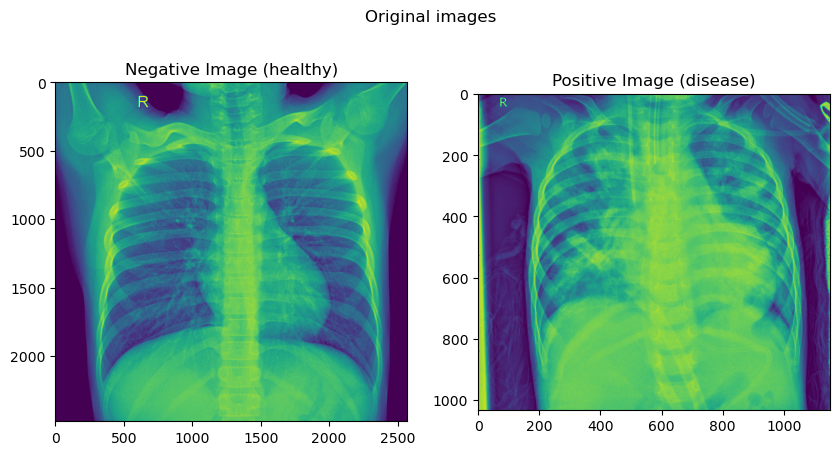

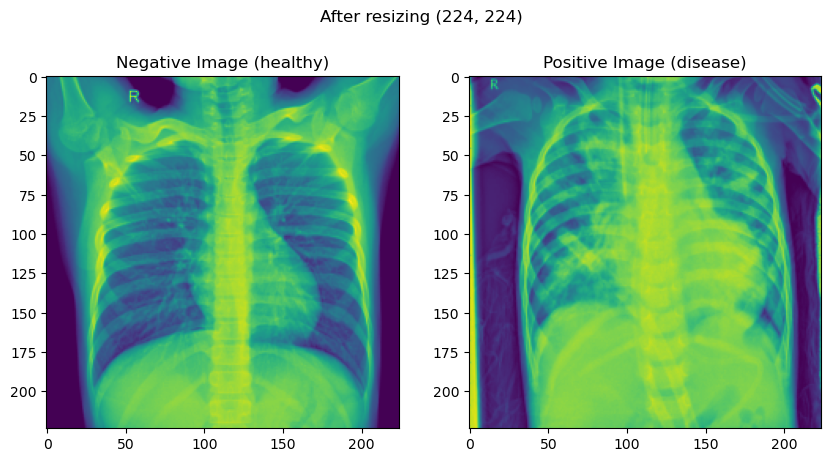

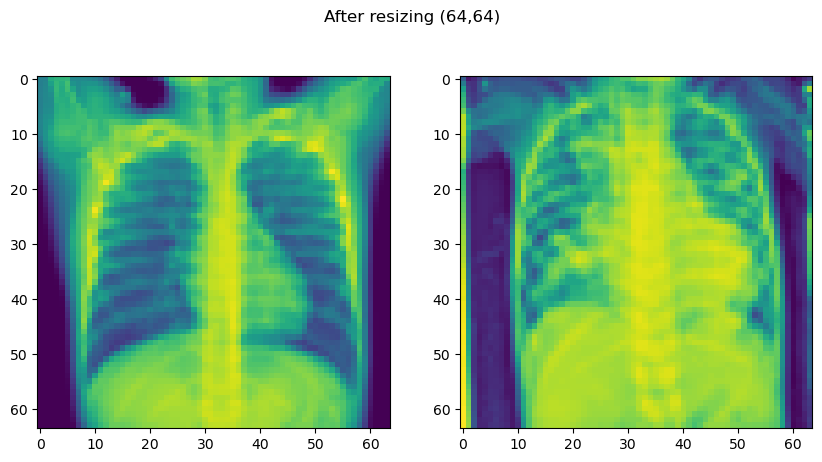

In [2]:
# Data processing

imgN = read_image( "data/NORMAL-1003233-0001.jpeg" )
imgP = read_image( "data/BACTERIA-1008087-0001.jpeg" )

print("Original size:")
print(imgN.shape , imgP.shape)

# Examples
fig,ax = plt.subplots(1,2 , figsize = (10,5))
ax[0].imshow(imgN.numpy()[0])
ax[1].imshow(imgP.numpy()[0])
fig.suptitle("Original images")
ax[0].set_title("Negative Image (healthy)")
ax[1].set_title("Positive Image (disease)")
plt.show()

# As they are, each image has its own size, and width to height ratio, so we will need to resize them to a common size first.
### We use the transformers from torchvision.v2

R = v2.Resize(size=(224, 224), antialias=True)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(R(imgN).numpy()[0])
ax[1].imshow(R(imgP).numpy()[0])

fig.suptitle("After resizing (224, 224)")  
ax[0].set_title("Negative Image (healthy)")
ax[1].set_title("Positive Image (disease)")
plt.show()


R = v2.Resize(size=(64, 64), antialias=True)
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("After resizing (64,64)")  
ax[0].imshow(R(imgN).numpy()[0])
ax[1].imshow(R(imgP).numpy()[0])

# Processing images 224x224

In this project, I implemented a simple 2-layer CNN backbone consisting of two convolutional blocks (Conv → ReLU → MaxPool) that extract low- and mid-level spatial features from chest X-ray images. The extracted features are then passed through three fully connected layers, with the final output neuron using a sigmoid activation for binary classification (NORMAL vs. PNEUMONIA). I'm gonna try to demonstrate that even small CNNs can effectively extract meaningful information from medical X-rays.

In [3]:

# Create an empty (untrained) CNN
model = create_model(DEVICE, input_size=224)

# Describe it (this calls torchinfo.summary inside describe_model)
describe_model(model, input_size=(1, 1, 224, 224)) # for 224×224


[INFO] Model architecture:

CNN(
  (conv): Sequential(
    (0): Conv2d(1, 2, kernel_size=(16, 16), stride=(4, 4))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(2, 4, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (classifier): Sequential(
    (0): Linear(in_features=484, out_features=16, bias=True)
    (1): Linear(in_features=16, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=1, bias=True)
    (3): Sigmoid()
  )
)

[INFO] Detailed summary:

[INFO] Total parameters: 8,623
[INFO] Trainable parameters: 8,623



## Train!

Let's train on the 224x224 images!
Training converged after 4 epochs due to early stopping. The CNN reached a training accuracy of about 74% and a validation accuracy of ~63%, with a best validation loss of 0.682. This suggests that the model learned to distinguish the classes but may still underfit the validation data-— a sign that deeper or pretrained models could perform better.

In [4]:

#train_main("config.yaml", 
#           ckpt_filename = "cnn_best_224x224.pt",
#           overrides={"paths": {"data_dir": "data/chest_xray_224"}},
#           loss_history_filename="loss_history_224x224.csv",
#           input_size=224)


Conceptually, the CNN learns hierarchical features: the first layer detects low-level edges and textures, the second combines them into mid-level shapes and regions, and the final linear layers use these for classification. In our visualization, one Conv1 filter fired strongly while others were suppressed, and all Conv2 filters became active, confirming that the model captures progressively more complex and meaningful structures in the X-ray image.


Pre-activation:

Positive (red) → regions where the convolution filter matched strongly → “this filter is detecting something interesting here”
Negative (blue) → regions where the filter anti-matched → “this filter suppresses that feature here”
White/gray → near zero → neutral activation
Then, in the next step, ReLU wipes out all the blues (negative values → 0), leaving only positive signals (what the network “cares about”).

Visualize kernels + activations for one example NORMAL and one PNEUMONIA X-ray image:

[check] total param change after load: 570.9


/tmp/ipykernel_488999/1766864927.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(CKPT_PATH, map_location=DEVICE)


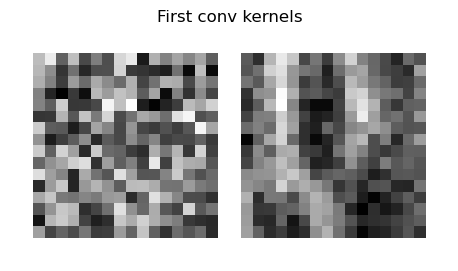

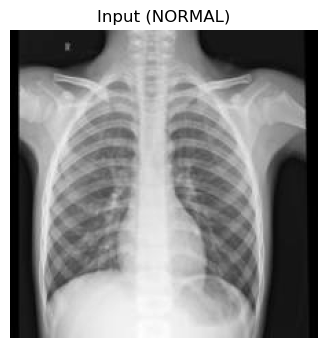

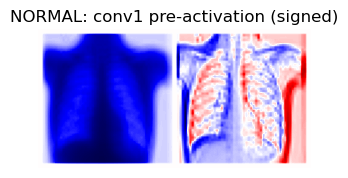

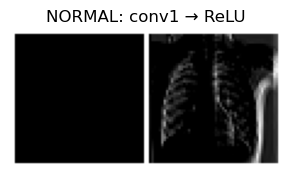

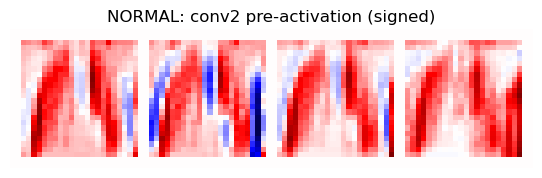

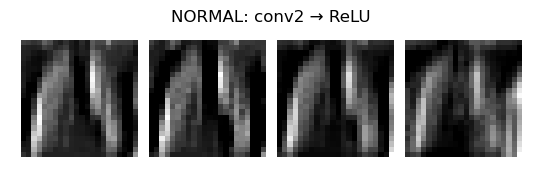


[stats] NORMAL
input     shape=(1, 1, 224, 224)  min=0.0000 max=0.8431 mean=0.4234 zeros=4.7%
conv1_pre shape=(1, 2, 53, 53)  min=0.0000 max=1.3267 mean=0.0563 zeros=77.5%
relu1     shape=(1, 2, 53, 53)  min=0.0000 max=1.3267 mean=0.0563 zeros=77.5%
pool1     shape=(1, 2, 26, 26)  min=0.0000 max=1.3267 mean=0.0880 zeros=69.2%
conv2_pre shape=(1, 4, 22, 22)  min=0.0000 max=2.4563 mean=0.4032 zeros=16.6%
relu2     shape=(1, 4, 22, 22)  min=0.0000 max=2.4563 mean=0.4032 zeros=16.6%
pool2     shape=(1, 4, 11, 11)  min=0.0000 max=2.4563 mean=0.5786 zeros=6.8%


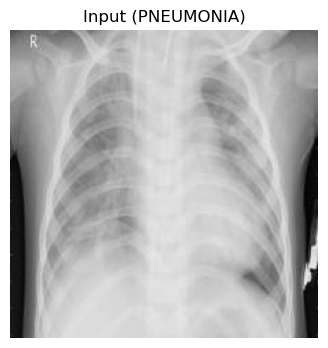

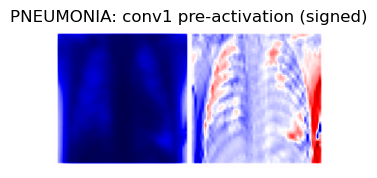

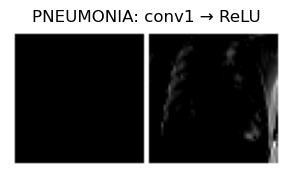

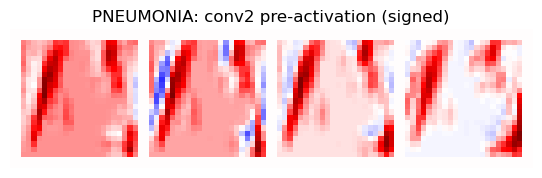

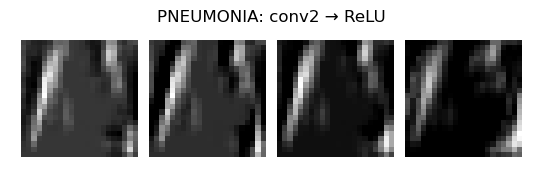


[stats] PNEUMONIA
input     shape=(1, 1, 224, 224)  min=0.0000 max=0.8980 mean=0.6121 zeros=0.0%
conv1_pre shape=(1, 2, 53, 53)  min=0.0000 max=1.4617 mean=0.0275 zeros=89.2%
relu1     shape=(1, 2, 53, 53)  min=0.0000 max=1.4617 mean=0.0275 zeros=89.2%
pool1     shape=(1, 2, 26, 26)  min=0.0000 max=1.4617 mean=0.0384 zeros=84.4%
conv2_pre shape=(1, 4, 22, 22)  min=0.0000 max=1.3925 mean=0.1934 zeros=16.7%
relu2     shape=(1, 4, 22, 22)  min=0.0000 max=1.3925 mean=0.1934 zeros=16.7%
pool2     shape=(1, 4, 11, 11)  min=0.0000 max=1.3925 mean=0.2728 zeros=7.0%


In [5]:
# ==== Visualize kernels + activations for one NORMAL and one PNEUMONIA ====

# If running from /notebooks, you may need:
# os.chdir("/home/katwre/projects/tmp_ml/ML-projects/CNN_and_TransferLearning_Xray")
# sys.path.append("src")
DATA_DIR   = "data/chest_xray_224"
CKPT_PATH  = "outputs/cnn_best_224x224.pt"
BATCH_SIZE = 32  # bigger to increase chance of seeing both classes in one batch

# ---------------- data & model ----------------
train_loader, val_loader, _ = make_loaders(DATA_DIR, batch_size=BATCH_SIZE, num_workers=0)

model = create_model(DEVICE, input_size=224)
sd_before = {k: v.clone() for k, v in model.state_dict().items()}
assert os.path.exists(CKPT_PATH), f"Checkpoint not found: {CKPT_PATH}"
state_dict = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(state_dict)
model.eval()
param_diff = sum((sd_before[k] - model.state_dict()[k]).abs().sum().item() for k in sd_before)
print(f"[check] total param change after load: {param_diff:.1f}")

# ---------------- small helpers ----------------
def _imshow_array(arr, title=None, cmap="gray", figsize=(4,4)):
    plt.figure(figsize=figsize)
    plt.imshow(arr, cmap=cmap)
    if title: plt.title(title)
    plt.axis("off"); plt.show()

def _imshow_grid(grid_tensor, title=None, cmap="gray", figsize=(8,3)):
    g = grid_tensor.detach().cpu().clamp(0, 1)         # [C,H,W]
    img = g.permute(1, 2, 0).numpy()                   # -> [H,W,C]
    plt.figure(figsize=figsize)
    if img.shape[-1] == 1: plt.imshow(img[..., 0], cmap=cmap)
    else: plt.imshow(img)
    if title: plt.title(title)
    plt.axis("off"); plt.show()

def show_first_conv_kernels(model, max_cols=8):
    conv1 = model.conv[0]                               # nn.Conv2d(1->2)
    w = conv1.weight.detach().cpu()                     # [out_c, in_c, kH, kW]
    w_min = w.amin(dim=(2,3), keepdim=True)
    w_max = w.amax(dim=(2,3), keepdim=True)
    w_norm = (w - w_min) / (w_max - w_min + 1e-8)       # normalize to [0,1]
    grid = make_grid(w_norm, nrow=min(max_cols, w_norm.shape[0]), pad_value=1.0)
    _imshow_grid(grid, title="First conv kernels", figsize=(6,3))

@torch.no_grad()
def get_acts_dict(model, x):
    acts = {}
    h = x
    h = model.conv[0](h); acts["conv1_pre"] = h.clone()
    h = model.conv[1](h); acts["relu1"]     = h.clone()
    h = model.conv[2](h); acts["pool1"]     = h.clone()
    h = model.conv[3](h); acts["conv2_pre"] = h.clone()
    h = model.conv[4](h); acts["relu2"]     = h.clone()
    h = model.conv[5](h); acts["pool2"]     = h.clone()
    return acts

def _per_channel_minmax_norm(fm):                       # fm: [C,H,W]
    cmin = fm.amin(dim=(1,2), keepdim=True)
    cmax = fm.amax(dim=(1,2), keepdim=True)
    return (fm - cmin) / (cmax - cmin + 1e-8)

def show_feature_maps(tensor, title, max_maps=8):
    """Post-activation view: per-channel min-max normalized to [0,1]."""
    fm = tensor[0].detach().cpu()                       # [C,H,W]
    n = min(fm.shape[0], max_maps)
    fm_norm = _per_channel_minmax_norm(fm[:n])
    grid = make_grid(fm_norm.unsqueeze(1), nrow=n, pad_value=1.0)
    _imshow_grid(grid, title=title, figsize=(1.8*n, 1.8))

def show_feature_maps_signed(tensor, title, max_maps=8):
    """Pre-activation view: symmetric scaling [-1,1] to see negatives vs positives."""
    fm = tensor[0].detach().cpu()                       # [C,H,W]
    n = min(fm.shape[0], max_maps)
    fm = fm[:n]
    a = fm.abs().amax(dim=(1,2), keepdim=True).clamp_min(1e-8)
    fm_sym = (fm / a).unsqueeze(1)                      # [-1,1] -> [n,1,H,W]
    grid = make_grid(fm_sym, nrow=n, pad_value=0.0)
    img = grid.permute(1,2,0).numpy()
    plt.figure(figsize=(1.8*n, 1.8))
    plt.imshow(img[...,0], cmap="seismic", vmin=-1, vmax=1)
    plt.title(title + " (signed)"); plt.axis("off"); plt.show()

@torch.no_grad()
def dump_stats(model, x, tag=""):
    h = x
    layers = [("input", h)]
    h = model.conv[0](h); layers += [("conv1_pre", h)]
    h = model.conv[1](h); layers += [("relu1", h)]
    h = model.conv[2](h); layers += [("pool1", h)]
    h = model.conv[3](h); layers += [("conv2_pre", h)]
    h = model.conv[4](h); layers += [("relu2", h)]
    h = model.conv[5](h); layers += [("pool2", h)]
    print(f"\n[stats] {tag}")
    for name, t in layers:
        t = t.detach().cpu()
        zeros = (t == 0).float().mean().item()*100
        print(f"{name:9s} shape={tuple(t.shape)}  "
              f"min={t.min().item():.4f} max={t.max().item():.4f} "
              f"mean={t.mean().item():.4f} zeros={zeros:.1f}%")

def find_one_of_each(val_loader):
    """Return (img_normal, img_pneumonia) as [1,1,H,W] tensors on DEVICE."""
    img_norm = None
    img_pneu = None
    for imgs, ys in val_loader:
        # ys could be shape [B,1] float -> flatten to [B]
        ys_flat = ys.view(ys.size(0), -1) if ys.ndim > 1 else ys.unsqueeze(1)
        for i in range(imgs.size(0)):
            y = int(ys_flat[i].view(-1)[0].item())
            if y == 0 and img_norm is None:
                img_norm = imgs[i:i+1].to(DEVICE)
            if y == 1 and img_pneu is None:
                img_pneu = imgs[i:i+1].to(DEVICE)
            if img_norm is not None and img_pneu is not None:
                return img_norm, img_pneu
    raise RuntimeError("Could not find both NORMAL (0) and PNEUMONIA (1) in val_loader.")

def visualize_single(model, img, label_text):
    # show input
    _imshow_array(img[0].detach().cpu().squeeze().numpy(), f"Input ({label_text})", figsize=(4,4))
    # activations
    acts = get_acts_dict(model, img)
    show_feature_maps_signed(acts["conv1_pre"], f"{label_text}: conv1 pre-activation",
                             max_maps=acts["conv1_pre"].shape[1])
    show_feature_maps(acts["relu1"], f"{label_text}: conv1 → ReLU",
                      max_maps=acts["relu1"].shape[1])
    show_feature_maps_signed(acts["conv2_pre"], f"{label_text}: conv2 pre-activation",
                             max_maps=acts["conv2_pre"].shape[1])
    show_feature_maps(acts["relu2"], f"{label_text}: conv2 → ReLU",
                      max_maps=acts["relu2"].shape[1])
    dump_stats(model, img, tag=label_text)

# ---------------- run: kernels once, then NORMAL and PNEUMONIA ----------------
show_first_conv_kernels(model)

img_norm, img_pneu = find_one_of_each(val_loader)

visualize_single(model, img_norm,  "NORMAL")
visualize_single(model, img_pneu,  "PNEUMONIA")



Side-by-side activation comparison of NORMAL vs PNEUMONIA for the same example images:

/tmp/ipykernel_488999/452562574.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))


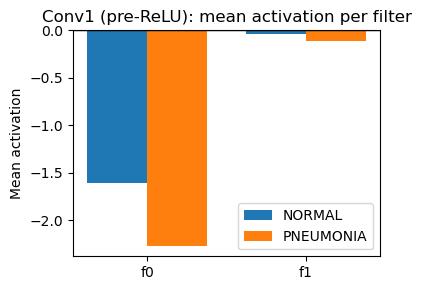

[Conv1 (pre-ReLU)] Normal means:   [-1.6126 -0.0426]
[Conv1 (pre-ReLU)] Pneumonia means:[-2.2667 -0.1081]


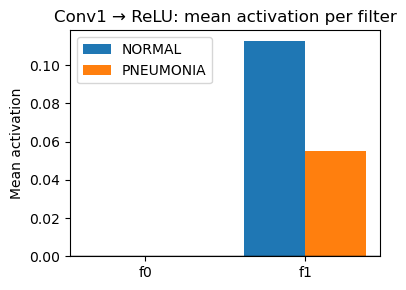

[Conv1 → ReLU] Normal means:   [0.     0.1126]
[Conv1 → ReLU] Pneumonia means:[0.    0.055]


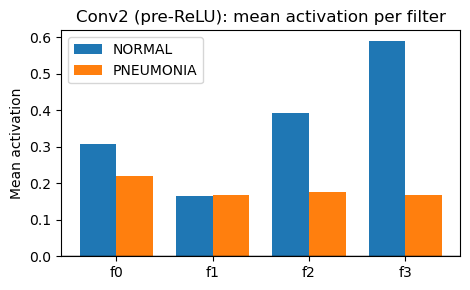

[Conv2 (pre-ReLU)] Normal means:   [0.3068 0.1652 0.3929 0.5901]
[Conv2 (pre-ReLU)] Pneumonia means:[0.2189 0.1687 0.1751 0.1678]


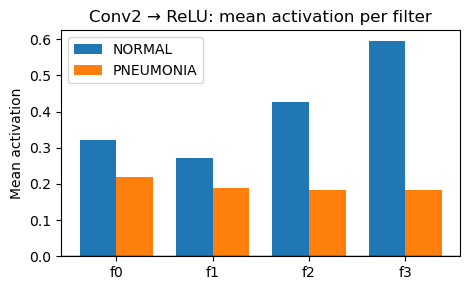

[Conv2 → ReLU] Normal means:   [0.3201 0.2715 0.4264 0.5947]
[Conv2 → ReLU] Pneumonia means:[0.2199 0.1881 0.1834 0.1822]


In [6]:

DATA_DIR = "data/chest_xray_224"
CKPT_PATH = "outputs/cnn_best_224x224.pt"

# 1) loaders & model
_, val_loader, _ = make_loaders(DATA_DIR, batch_size=16, num_workers=0)
model = create_model(DEVICE, input_size=224)
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

# 2) helpers ----------------------------------------------------
def _to_scalar(y):
    # y could be tensor([0.]) or scalar; normalize to int 0/1
    if isinstance(y, torch.Tensor):
        return int(y.view(-1)[0].item())
    return int(y)

@torch.no_grad()
def get_one_example_by_label(loader, target_label: int):
    """Return a single image [1,1,H,W] for the given label (0=Normal, 1=Pneumonia)."""
    for imgs, ys in loader:
        # ys might be shape [B,1] float; squeeze to [B]
        ys_flat = ys.view(ys.size(0), -1) if ys.ndim > 1 else ys.unsqueeze(1)
        for i in range(imgs.size(0)):
            if _to_scalar(ys_flat[i]) == target_label:
                return imgs[i:i+1].to(DEVICE), target_label
    raise RuntimeError(f"Could not find an example with label={target_label}")

@torch.no_grad()
def get_acts(model, x):
    """Return a dict of activations for key stages."""
    acts = {}
    h = x
    h = model.conv[0](h); acts["conv1_pre"] = h.clone()
    h = model.conv[1](h); acts["relu1"]     = h.clone()
    h = model.conv[2](h); acts["pool1"]     = h.clone()
    h = model.conv[3](h); acts["conv2_pre"] = h.clone()
    h = model.conv[4](h); acts["relu2"]     = h.clone()
    h = model.conv[5](h); acts["pool2"]     = h.clone()
    return acts

def per_filter_means(t: torch.Tensor) -> np.ndarray:
    """t: [B,C,H,W] -> mean over H,W for first sample -> [C] numpy."""
    return t[0].detach().cpu().mean(dim=(1,2)).numpy()

def plot_grouped_bars(means_A, means_B, title, label_A="NORMAL", label_B="PNEUMONIA"):
    C = len(means_A)
    x = np.arange(C)
    w = 0.38
    plt.figure(figsize=(max(4, C*1.2), 3.0))
    plt.bar(x - w/2, means_A, width=w, label=label_A)
    plt.bar(x + w/2, means_B, width=w, label=label_B)
    plt.axhline(0, color="black", lw=1)
    plt.xticks(x, [f"f{i}" for i in x])
    plt.ylabel("Mean activation")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def show_gray(img, title):
    arr = img[0].detach().cpu().squeeze().numpy()
    plt.figure(figsize=(3.2,3.2))
    plt.imshow(arr, cmap="gray"); plt.title(title); plt.axis("off"); plt.show()

# 3) pick one NORMAL & one PNEUMONIA ----------------------------
img_norm, _ = get_one_example_by_label(val_loader, 0)
img_pneu, _ = get_one_example_by_label(val_loader, 1)

#show_gray(img_norm, "NORMAL example")
#show_gray(img_pneu, "PNEUMONIA example")

# 4) activations & side-by-side summaries -----------------------
acts_norm = get_acts(model, img_norm)
acts_pneu = get_acts(model, img_pneu)

for key, nice in [
    ("conv1_pre", "Conv1 (pre-ReLU)"),
    ("relu1",     "Conv1 → ReLU"),
    ("conv2_pre", "Conv2 (pre-ReLU)"),
    ("relu2",     "Conv2 → ReLU"),
]:
    mA = per_filter_means(acts_norm[key])
    mB = per_filter_means(acts_pneu[key])
    plot_grouped_bars(mA, mB, f"{nice}: mean activation per filter")
    print(f"[{nice}] Normal means:   {np.round(mA, 4)}")
    print(f"[{nice}] Pneumonia means:{np.round(mB, 4)}")



How is the loss looking?

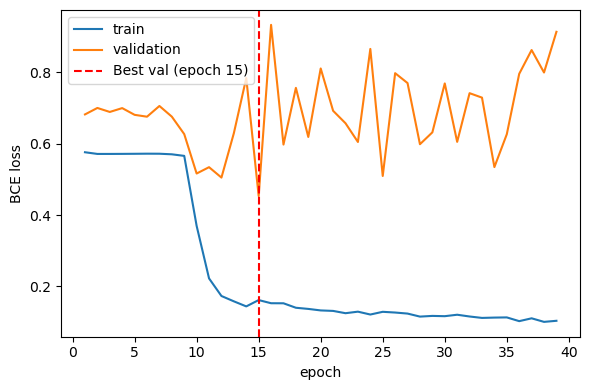

Best validation loss at epoch 15: 0.4536


In [7]:


def plot_losses_from_csv(csv_path="outputs/loss_history.csv", ylabel="BCE loss"):
    # Load CSV (skip header)
    epochs, train_losses, val_losses = np.loadtxt(csv_path, delimiter=",", skiprows=1, unpack=True)

    early_stop_epoch = int(np.argmin(val_losses) + 1)

    plt.figure(figsize=(6,4))
    plt.plot(epochs, train_losses, label="train")
    plt.plot(epochs, val_losses, label="validation")
    plt.axvline(early_stop_epoch, linestyle="--", color="r", label=f"Best val (epoch {early_stop_epoch})")
    plt.xlabel("epoch")
    plt.ylabel(ylabel)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Best validation loss at epoch {early_stop_epoch}: {val_losses[early_stop_epoch-1]:.4f}")

# Run it
plot_losses_from_csv("outputs/loss_history_224x224.csv")


It's not the greatest, but it is already fairly nice! The model is definitely learning - it’s fitting the training data well. Validation looss was initially around 0.6–0.7, dips a bit, then spikes up and oscillates quite a lot. The model starts overfitting after about epoch 15, when validation loss stops improving and the validation loss increases while training loss continues to fall - the model is starting to memorize rather than generalize. The red dashed line correctly marks that early stopping checkpoint.

Let's check out some stats on the evaluation of this model. AUC is 0.928 - that’s very strong discriminative power. The model clearly separates NORMAL and PNEUMONIA quite well overall. The ROC curve rises steeply - meaning your model achieves high sensitivity (true positives) with relatively low false positives. Even if the default threshold (0.5) isn't optimal, the model's internal probability ranking is very good - it “knows” which cases look more pneumonia-like.

At the default decision cutoff (0.5): 

- The model is very cautious about calling something NORMAL → high precision but lower recall.
- It catches almost all PNEUMONIA (recall = 0.97), but sometimes mislabels NORMALs as pneumonia.
- Ity tends tends to "play safe" and over-call disease


Best threshold via Youden’s J is 0.873. The confusion matrices show a healthier balance — false alarms (NORMAL→PNEUMONIA) drop sharply, while true pneumonia detections remain strong. This threshold (0.87) is a much better clinical tradeoff if we want fewer false positives. So, the model is tiny bit over-sensitive at default 0.5, but fixable via threshold tuning.


/tmp/ipykernel_488999/944216404.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(CKPT_PATH, map_location=DEVICE)


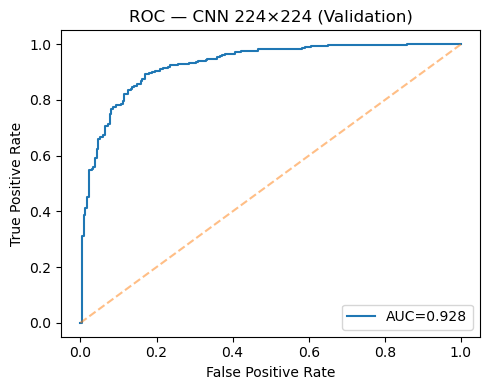

=== Validation @ threshold 0.5 ===
              precision    recall  f1-score   support

      NORMAL     0.9306    0.5726    0.7090       234
   PNEUMONIA     0.7917    0.9744    0.8736       390

    accuracy                         0.8237       624
   macro avg     0.8611    0.7735    0.7913       624
weighted avg     0.8438    0.8237    0.8119       624


Best threshold by Youden's J: 0.8728
              precision    recall  f1-score   support

      NORMAL     0.8220    0.8291    0.8255       234
   PNEUMONIA     0.8969    0.8923    0.8946       390

    accuracy                         0.8686       624
   macro avg     0.8595    0.8607    0.8601       624
weighted avg     0.8688    0.8686    0.8687       624



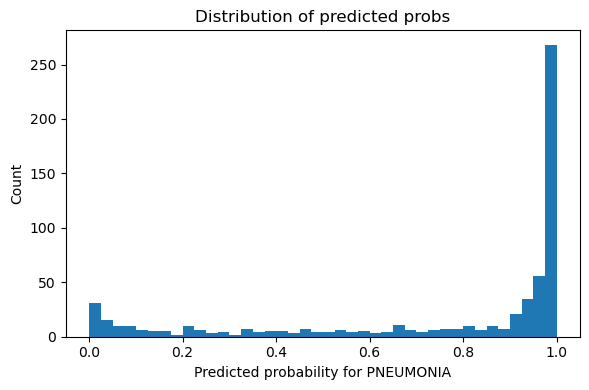

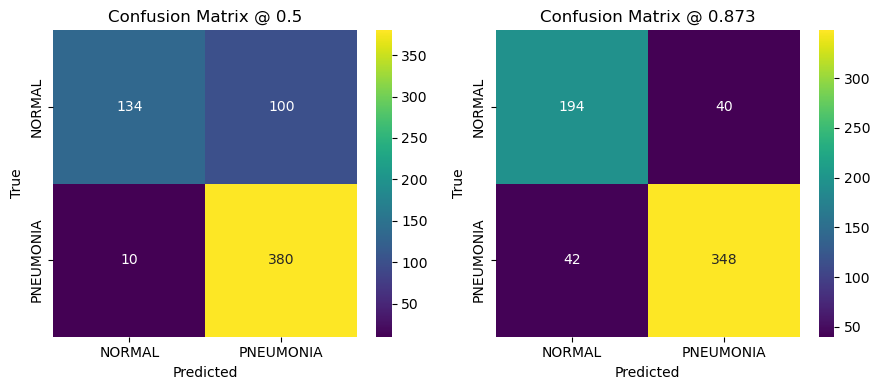

In [8]:
# ==== Full evaluation & plots (ROC, thresholds, hist, confusion matrices) ====

DATA_DIR   = "data/chest_xray_224"     # or "data/chest_xray_64"
CKPT_PATH  = "outputs/cnn_best_224x224.pt"     # change if you used another filename
INPUT_SIZE = 224                       # 64 if you trained the 64×64 version
BATCH_SIZE = 64

# 1) Load data & model
_, val_loader, _ = make_loaders(DATA_DIR, batch_size=BATCH_SIZE, num_workers=0)
model = create_model(DEVICE, input_size=INPUT_SIZE).eval()
state = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(state)

# 2) Collect probabilities and labels on validation set
probs, ys = [], []
model.eval()
with torch.no_grad():
    for x, y in val_loader:
        x = x.to(DEVICE)
        p = model(x).squeeze(1)               # [B]
        probs.append(p.cpu().numpy())
        ys.append(y.view(-1).cpu().numpy())   # y may be [B,1] floats -> flatten to [B]
probs = np.concatenate(probs).astype(float)
ys    = np.concatenate(ys).astype(int)

# 3) ROC + AUC
fpr, tpr, thr = roc_curve(ys, probs)
auc = roc_auc_score(ys, probs)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1], [0,1], "--", alpha=0.5)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title(f"ROC — CNN {INPUT_SIZE}×{INPUT_SIZE} (Validation)")
plt.legend(); plt.tight_layout(); plt.show()

# 4) Metrics at threshold 0.5
def binarize(p, th): return (p >= th).astype(int)

print("=== Validation @ threshold 0.5 ===")
pred05 = binarize(probs, 0.5)
print(classification_report(ys, pred05, target_names=["NORMAL","PNEUMONIA"], digits=4))
cm05 = confusion_matrix(ys, pred05)

# 5) Find best threshold by Youden's J (argmax of TPR - FPR)
youden_idx = np.argmax(tpr - fpr)
best_th    = thr[youden_idx]
print(f"\nBest threshold by Youden's J: {best_th:.4f}")
pred_best = binarize(probs, best_th)
print(classification_report(ys, pred_best, target_names=["NORMAL","PNEUMONIA"], digits=4))
cmb = confusion_matrix(ys, pred_best)

# 6) Histogram of predicted probabilities
plt.figure(figsize=(6,4))
plt.hist(probs, bins=40)
plt.xlabel("Predicted probability for PNEUMONIA"); plt.ylabel("Count")
plt.title("Distribution of predicted probs")
plt.tight_layout(); plt.show()

# 7) Side-by-side confusion matrices (0.5 vs best)
fig, axes = plt.subplots(1, 2, figsize=(9,4))
sns.heatmap(cm05, annot=True, fmt="d", cmap="viridis", cbar=True, ax=axes[0])
axes[0].set_title("Confusion Matrix @ 0.5")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
axes[0].set_xticklabels(["NORMAL","PNEUMONIA"]); axes[0].set_yticklabels(["NORMAL","PNEUMONIA"])

sns.heatmap(cmb, annot=True, fmt="d", cmap="viridis", cbar=True, ax=axes[1])
axes[1].set_title(f"Confusion Matrix @ {best_th:.3f}")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
axes[1].set_xticklabels(["NORMAL","PNEUMONIA"]); axes[1].set_yticklabels(["NORMAL","PNEUMONIA"])

plt.tight_layout(); plt.show()


# Processing images 64x64

Above, I've used 224x224 images there. But maybe for this fairly simple task one could use much smaller images and still get an ok results?

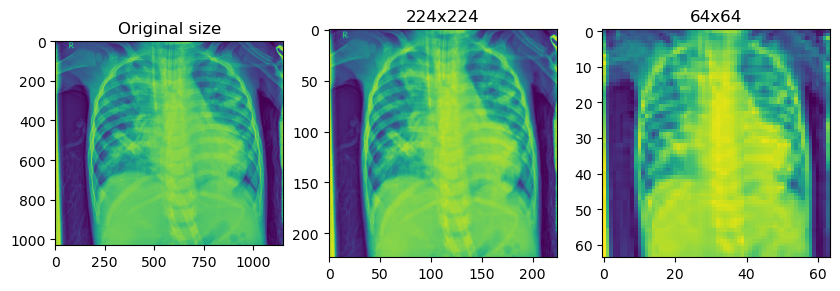

In [9]:
imgFull    = read_image( "data/BACTERIA-1008087-0001.jpeg" )
imgReduced224 = read_image( "data/chest_xray_224/train/PNEUMONIA/PNEUMONIA_1349.jpeg" )
imgReduced64 = read_image( "data/chest_xray_64/train/PNEUMONIA/PNEUMONIA_1349.jpeg" )

fig,ax = plt.subplots(1, 3, figsize = (10,5))
ax[0].imshow(imgFull.numpy()[0])
ax[1].imshow(imgReduced224.numpy()[0])
ax[2].imshow(imgReduced64.numpy()[0])
ax[0].set_title("Original size")
ax[1].set_title("224x224")
ax[2].set_title("64x64")
plt.show()


In [10]:
# Create an empty (untrained) CNN
model64 = create_model(DEVICE, input_size=64)

# Describe it (this calls torchinfo.summary inside describe_model)
describe_model(model64, input_size=(1, 1, 64, 64)) 


[INFO] Model architecture:

CNN(
  (conv): Sequential(
    (0): Conv2d(1, 2, kernel_size=(16, 16), stride=(4, 4))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(2, 4, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (classifier): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): Linear(in_features=16, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=1, bias=True)
    (3): Sigmoid()
  )
)

[INFO] Detailed summary:

[INFO] Total parameters: 943
[INFO] Trainable parameters: 943



In [11]:
#train_main("config.yaml", 
#           ckpt_filename = "cnn_best_64x64.pt",
#           overrides={"paths": {"data_dir": "data/chest_xray_64"}},
#           loss_history_filename="loss_history_64x64.csv",
#           input_size=64)

[check] total param change after load: 116.1


/tmp/ipykernel_488999/2502707874.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(CKPT_PATH, map_location=DEVICE)


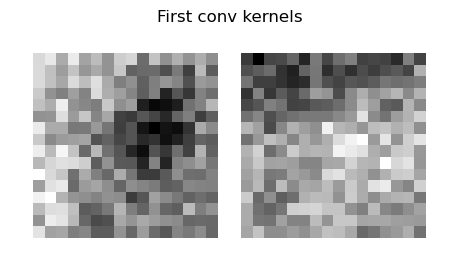

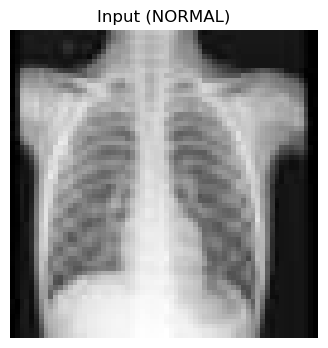

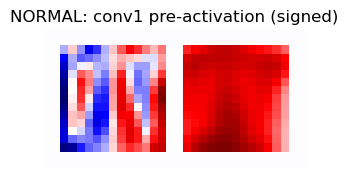

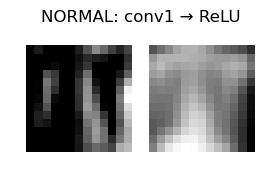

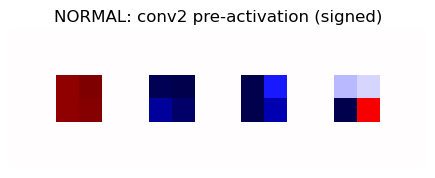

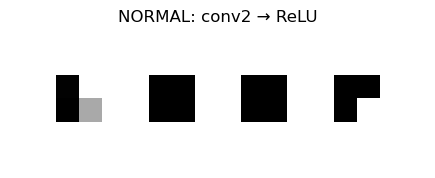


[stats] NORMAL
input     shape=(1, 1, 64, 64)  min=0.0000 max=0.8275 mean=0.4235 zeros=2.9%
conv1_pre shape=(1, 2, 13, 13)  min=0.0000 max=11.7823 mean=3.8100 zeros=23.1%
relu1     shape=(1, 2, 13, 13)  min=0.0000 max=11.7823 mean=3.8100 zeros=23.1%
pool1     shape=(1, 2, 6, 6)  min=0.0000 max=11.2859 mean=4.3287 zeros=15.3%
conv2_pre shape=(1, 4, 2, 2)  min=0.0000 max=9.9233 mean=2.4023 zeros=68.8%
relu2     shape=(1, 4, 2, 2)  min=0.0000 max=9.9233 mean=2.4023 zeros=68.8%
pool2     shape=(1, 4, 1, 1)  min=0.0000 max=9.9233 mean=2.6139 zeros=50.0%


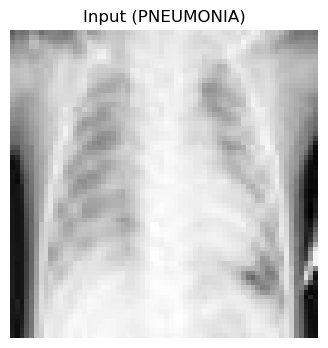

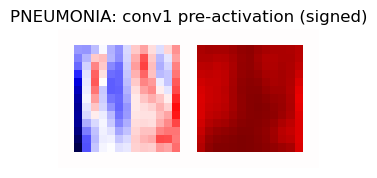

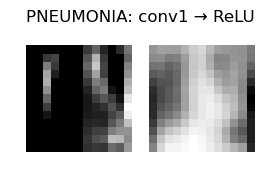

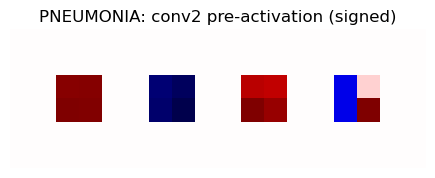

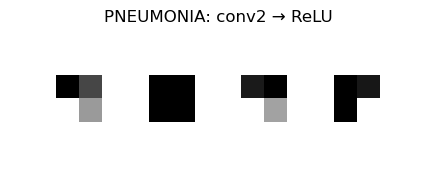


[stats] PNEUMONIA
input     shape=(1, 1, 64, 64)  min=0.0000 max=0.8039 mean=0.6120 zeros=0.0%
conv1_pre shape=(1, 2, 13, 13)  min=0.0000 max=11.4073 mean=4.8835 zeros=26.3%
relu1     shape=(1, 2, 13, 13)  min=0.0000 max=11.4073 mean=4.8835 zeros=26.3%
pool1     shape=(1, 2, 6, 6)  min=0.0000 max=11.3787 mean=5.1396 zeros=19.4%
conv2_pre shape=(1, 4, 2, 2)  min=0.0000 max=11.3904 mean=3.5039 zeros=37.5%
relu2     shape=(1, 4, 2, 2)  min=0.0000 max=11.3904 mean=3.5039 zeros=37.5%
pool2     shape=(1, 4, 1, 1)  min=0.0000 max=11.3904 mean=3.8076 zeros=25.0%


In [12]:
DATA_DIR   = "data/chest_xray_64"
CKPT_PATH  = "outputs/cnn_best_64x64.pt"
BATCH_SIZE = 32  # bigger to increase chance of seeing both classes in one batch

# ---------------- data & model ----------------
train_loader, val_loader, _ = make_loaders(DATA_DIR, batch_size=BATCH_SIZE, num_workers=0)

model64 = create_model(DEVICE, input_size=64)
sd_before = {k: v.clone() for k, v in model64.state_dict().items()}
assert os.path.exists(CKPT_PATH), f"Checkpoint not found: {CKPT_PATH}"
state_dict = torch.load(CKPT_PATH, map_location=DEVICE)
model64.load_state_dict(state_dict)
model64.eval()
param_diff = sum((sd_before[k] - model64.state_dict()[k]).abs().sum().item() for k in sd_before)
print(f"[check] total param change after load: {param_diff:.1f}")

# ---------------- vis ----------------


show_first_conv_kernels(model64)

img_norm, img_pneu = find_one_of_each(val_loader)

visualize_single(model64, img_norm,  "NORMAL")
visualize_single(model64, img_pneu,  "PNEUMONIA")


We're left with 2x2 final feature maps and it's not great for visualization or interpretability, but for simple classification only. 2×2 is okay, because my goal is binary classification (NORMAL vs PNEUMONIA). By the time we reach conv2 → ReLU, the CNN has hopefully already extracted most spatial features (edges, textures, densities, etc.)

/tmp/ipykernel_488999/2265237940.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))


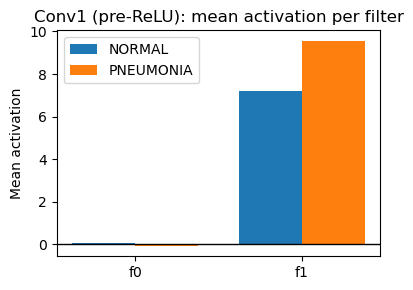

[Conv1 (pre-ReLU)] Normal means:   [0.0577 7.2255]
[Conv1 (pre-ReLU)] Pneumonia means:[-0.0714  9.571 ]


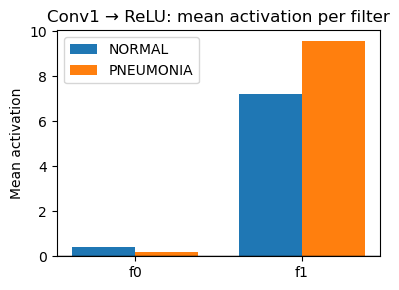

[Conv1 → ReLU] Normal means:   [0.3945 7.2255]
[Conv1 → ReLU] Pneumonia means:[0.196 9.571]


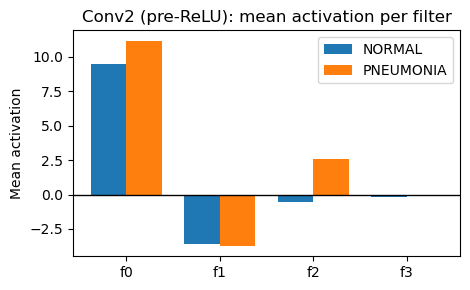

[Conv2 (pre-ReLU)] Normal means:   [ 9.4761 -3.5783 -0.5447 -0.1782]
[Conv2 (pre-ReLU)] Pneumonia means:[ 1.11919e+01 -3.74230e+00  2.61090e+00 -4.70000e-03]


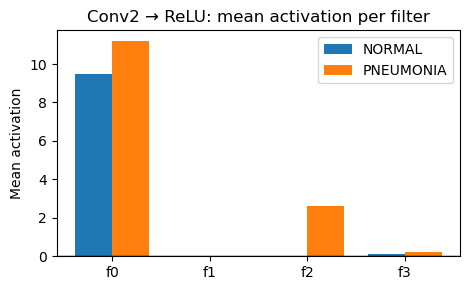

[Conv2 → ReLU] Normal means:   [9.4761 0.     0.     0.1331]
[Conv2 → ReLU] Pneumonia means:[11.1919  0.      2.6109  0.2129]


In [13]:
DATA_DIR = "data/chest_xray_64"
CKPT_PATH = "outputs/cnn_best_64x64.pt"

# 1) loaders & model
_, val_loader, _ = make_loaders(DATA_DIR, batch_size=16, num_workers=0)
model = create_model(DEVICE, input_size=64)
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

# 3) pick one NORMAL & one PNEUMONIA ----------------------------
img_norm, _ = get_one_example_by_label(val_loader, 0)
img_pneu, _ = get_one_example_by_label(val_loader, 1)

#show_gray(img_norm, "NORMAL example")
#show_gray(img_pneu, "PNEUMONIA example")

# 4) activations & side-by-side summaries -----------------------
acts_norm = get_acts(model, img_norm)
acts_pneu = get_acts(model, img_pneu)

for key, nice in [
    ("conv1_pre", "Conv1 (pre-ReLU)"),
    ("relu1",     "Conv1 → ReLU"),
    ("conv2_pre", "Conv2 (pre-ReLU)"),
    ("relu2",     "Conv2 → ReLU"),
]:
    mA = per_filter_means(acts_norm[key])
    mB = per_filter_means(acts_pneu[key])
    plot_grouped_bars(mA, mB, f"{nice}: mean activation per filter")
    print(f"[{nice}] Normal means:   {np.round(mA, 4)}")
    print(f"[{nice}] Pneumonia means:{np.round(mB, 4)}")

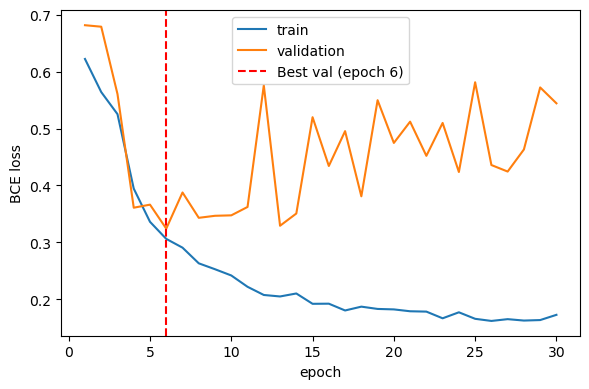

Best validation loss at epoch 6: 0.3242


In [14]:
# How does the loss look like?
plot_losses_from_csv("outputs/loss_history_64x64.csv")

In the case of our 64x64 images AUC is 0.936 which is excellent. This is even slightly higher than your 224×224 model (AUC=0.928)! The model is still slightly more sensitive to pneumonia (recall=0.93) - but without severely over-calling it. At the default threshold (0.5), this model achieves solid accuracy and high pneumonia sensitivity. It’s already well-calibrated.

OPur 64×64 model is surprisingly strong - nearly identical performance to 224×224 but smaller and computationally lighter! Pneumonia vs normal classification is driven by global features (density, brightness, lung shape), not fine detail. We’ve achieved excellent feature learning efficiency — the convolution filters are working well.

/tmp/ipykernel_488999/4188816613.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(CKPT_PATH, map_location=DEVICE)


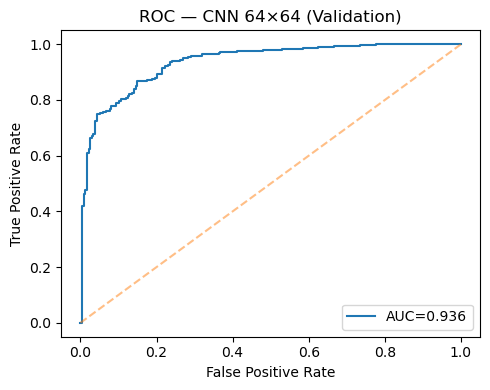

=== Validation @ threshold 0.5 ===
              precision    recall  f1-score   support

      NORMAL     0.8606    0.7650    0.8100       234
   PNEUMONIA     0.8678    0.9256    0.8958       390

    accuracy                         0.8654       624
   macro avg     0.8642    0.8453    0.8529       624
weighted avg     0.8651    0.8654    0.8636       624


Best threshold by Youden's J: 0.6297
              precision    recall  f1-score   support

      NORMAL     0.7928    0.8504    0.8206       234
   PNEUMONIA     0.9062    0.8667    0.8860       390

    accuracy                         0.8606       624
   macro avg     0.8495    0.8585    0.8533       624
weighted avg     0.8637    0.8606    0.8615       624



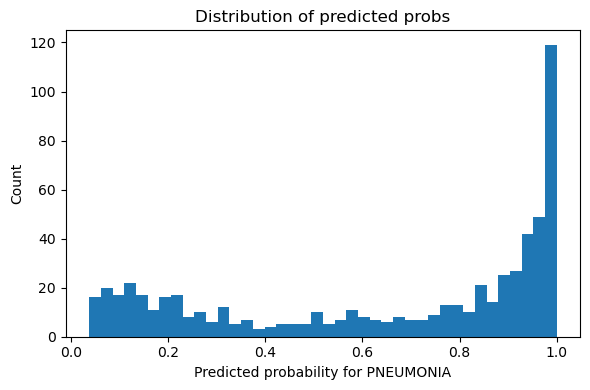

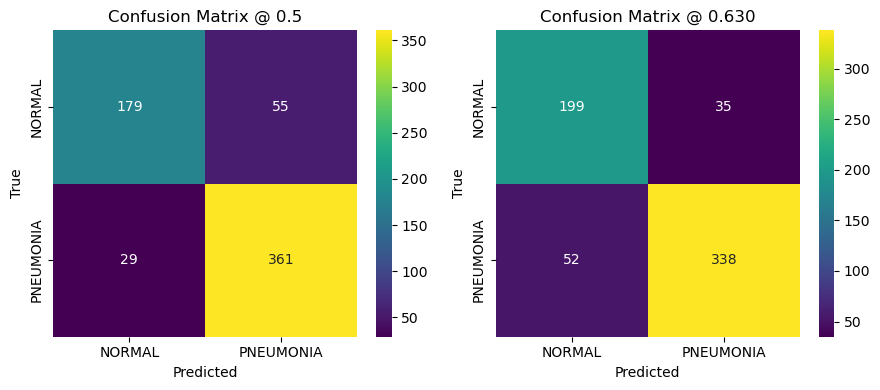

In [15]:
# ==== Full evaluation & plots (ROC, thresholds, hist, confusion matrices) ====

DATA_DIR   = "data/chest_xray_64"    
CKPT_PATH  = "outputs/cnn_best_64x64.pt"    
INPUT_SIZE = 64                     
BATCH_SIZE = 64

# 1) Load data & model
_, val_loader, _ = make_loaders(DATA_DIR, batch_size=BATCH_SIZE, num_workers=0)
model = create_model(DEVICE, input_size=INPUT_SIZE).eval()
state = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(state)

# 2) Collect probabilities and labels on validation set
probs, ys = [], []
model.eval()
with torch.no_grad():
    for x, y in val_loader:
        x = x.to(DEVICE)
        p = model(x).squeeze(1)               # [B]
        probs.append(p.cpu().numpy())
        ys.append(y.view(-1).cpu().numpy())   # y may be [B,1] floats -> flatten to [B]
probs = np.concatenate(probs).astype(float)
ys    = np.concatenate(ys).astype(int)

# 3) ROC + AUC
fpr, tpr, thr = roc_curve(ys, probs)
auc = roc_auc_score(ys, probs)

plt.figure(figsize=(5,4))
plt.plot(fpr, tpr, label=f"AUC={auc:.3f}")
plt.plot([0,1], [0,1], "--", alpha=0.5)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title(f"ROC — CNN {INPUT_SIZE}×{INPUT_SIZE} (Validation)")
plt.legend(); plt.tight_layout(); plt.show()

# 4) Metrics at threshold 0.5
def binarize(p, th): return (p >= th).astype(int)

print("=== Validation @ threshold 0.5 ===")
pred05 = binarize(probs, 0.5)
print(classification_report(ys, pred05, target_names=["NORMAL","PNEUMONIA"], digits=4))
cm05 = confusion_matrix(ys, pred05)

# 5) Find best threshold by Youden's J (argmax of TPR - FPR)
youden_idx = np.argmax(tpr - fpr)
best_th    = thr[youden_idx]
print(f"\nBest threshold by Youden's J: {best_th:.4f}")
pred_best = binarize(probs, best_th)
print(classification_report(ys, pred_best, target_names=["NORMAL","PNEUMONIA"], digits=4))
cmb = confusion_matrix(ys, pred_best)

# 6) Histogram of predicted probabilities
plt.figure(figsize=(6,4))
plt.hist(probs, bins=40)
plt.xlabel("Predicted probability for PNEUMONIA"); plt.ylabel("Count")
plt.title("Distribution of predicted probs")
plt.tight_layout(); plt.show()

# 7) Side-by-side confusion matrices (0.5 vs best)
fig, axes = plt.subplots(1, 2, figsize=(9,4))
sns.heatmap(cm05, annot=True, fmt="d", cmap="viridis", cbar=True, ax=axes[0])
axes[0].set_title("Confusion Matrix @ 0.5")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
axes[0].set_xticklabels(["NORMAL","PNEUMONIA"]); axes[0].set_yticklabels(["NORMAL","PNEUMONIA"])

sns.heatmap(cmb, annot=True, fmt="d", cmap="viridis", cbar=True, ax=axes[1])
axes[1].set_title(f"Confusion Matrix @ {best_th:.3f}")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
axes[1].set_xticklabels(["NORMAL","PNEUMONIA"]); axes[1].set_yticklabels(["NORMAL","PNEUMONIA"])

plt.tight_layout(); plt.show()
